# 프로젝트 지침

- 항상 한국어로 답변할 것. 설명, 코드 주석, 커밋 메시지 모두 한국어로.
- 영어로 답하지 말 것.
-앞으로 이 세션에서는 무조건 한국어로만 답해. CLAUDE.md에도 이 내용 추가해줘.

# 파일 불러오기

In [1]:
import glob
import os
import pandas as pd

folder = r"C:\Users\seohg\OneDrive\바탕 화면\2026\seoul datalob contest\store_name_1525\data"
files = sorted(glob.glob(os.path.join(folder, "*.csv")))

dfs = {}
for file in files:
    name = os.path.splitext(os.path.basename(file))[0]
    df = pd.read_csv(file, low_memory=False)
    df["period"] = int(name)  # 파일명(YYYYMM)을 수치형 period로 저장
    dfs[name] = df

# 컬럼이 모두 같다면
df_all = pd.concat(dfs.values(), ignore_index=True)

In [2]:
df_all

,상가업소번호,상호명,지점명,상권업종대분류코드,상권업종대분류명,상권업종중분류코드,상권업종중분류명,상권업종소분류코드,상권업종소분류명,표준산업분류코드,...,건물명,도로명주소,구우편번호,신우편번호,동정보,층정보,호정보,경도,위도,period
0,MA010120220808288418,숲,NaN,I2,음식,I212,비알코올,I21201,카페,I56221,...,르메이에르종로타운,서울특별시 종로구 종로 19,110888,3157,NaN,1,NaN,126.979919,37.570852,201512
1,MA010120220804265295,60계치킨암사,선사점,I2,음식,I210,기타 간이,I21006,치킨,I56193,...,암사동정웅빌딩,서울특별시 강동구 상암로3길 8,134877,5241,NaN,1,NaN,127.126859,37.550810,201512
2,MA010120220800735075,커피볶는집모모,NaN,I2,음식,I212,비알코올,I21201,카페,I56221,...,태영빌딩,서울특별시 구로구 새말로 89,152838,8288,NaN,NaN,NaN,126.889842,37.505615,201512
3,MA010120220804370987,까치노래연습장,NaN,R1,예술·스포츠,R104,유원지·오락,R10407,노래방,R91223,...,NaN,서울특별시 노원구 한글비석로23길 2,139815,1682,NaN,NaN,NaN,127.071218,37.660715,201512
4,MA010120220800201814,블루림,NaN,G2,소매,G209,섬유·의복·신발 소매,G20911,가방 소매업,G47440,...,NaN,서울특별시 종로구 창의문로9길 1,110818,3022,NaN,NaN,NaN,126.963800,37.592634,201512
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19079678,MA0106202511A1072506,살림,NaN,G2,소매,G221,기타 상품 소매,G22199,그 외 기타 상품 전문 소매업,G47859,...,NaN,서울특별시 송파구 올림픽로 119,138908,5501,NaN,NaN,NaN,127.084186,37.512087,202512
19079679,MA0106202511A2270156,연막창건대,직영점,I2,음식,I201,한식,I20109,곱창 전골/구이,I56111,...,NaN,서울특별시 광진구 동일로24길 101,143914,5016,NaN,NaN,NaN,127.070563,37.542406,202512
19079680,MA0106202511A0034578,하루곰탕,NaN,I2,음식,I201,한식,I20102,국/탕/찌개류,I56111,...,NaN,서울특별시 동대문구 사가정로25길 21,130835,2516,NaN,NaN,NaN,127.070371,37.579807,202512
19079681,MA0106202511A2056843,만월다방,한강점,I2,음식,I212,비알코올,I21201,카페,I56221,...,NaN,서울특별시 마포구 토정로 130,121829,4081,NaN,NaN,NaN,126.925497,37.545062,202512


In [3]:
df_all.columns

Index(['상가업소번호', '상호명', '지점명', '상권업종대분류코드', '상권업종대분류명', '상권업종중분류코드',
       '상권업종중분류명', '상권업종소분류코드', '상권업종소분류명', '표준산업분류코드', '표준산업분류명', '시도코드',
       '시도명', '시군구코드', '시군구명', '행정동코드', '행정동명', '법정동코드', '법정동명', '지번코드',
       '대지구분코드', '대지구분명', '지번본번지', '지번부번지', '지번주소', '도로명코드', '도로명', '건물본번지',
       '건물부번지', '건물관리번호', '건물명', '도로명주소', '구우편번호', '신우편번호', '동정보', '층정보',
       '호정보', '경도', '위도', 'period'],
      dtype='object')

In [4]:
print("hello")

hello


# PK설정

In [5]:
df_all.groupby('상가업소번호')['상호명'].nunique()

상가업소번호
MA010120220700000009    1
MA010120220700000274    1
MA010120220700000340    1
MA010120220700000415    1
MA010120220700000544    1
                       ..
MA0106202511A2473203    1
MA0106202511A2473329    1
MA0106202511A2473988    1
MA0106202511A2474197    1
MA0106202511A2474521    1
Name: 상호명, Length: 1114197, dtype: int64

## 상호명 중복자 확인

C:\Users\seohg\AppData\Local\Temp\ipykernel_7132\665360214.py:17: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\seohg\AppData\Local\Temp\ipykernel_7132\665360214.py:17: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\seohg\AppData\Local\Temp\ipykernel_7132\665360214.py:17: UserWarning: Glyph 50629 (\N{HANGUL SYLLABLE EOB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\seohg\AppData\Local\Temp\ipykernel_7132\665360214.py:17: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\seohg\AppData\Local\Temp\ipykernel_7132\665360214.py:17: UserWarning: Glyph 48264 (\N{HANGUL SYLLABLE BEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\seohg\AppData\Local\Temp\ipykernel_7132\665360214.py:17: UserWarning: Glyph 54840 (\N{HANGUL SYLLABLE HO}) missing from font(s) Dej

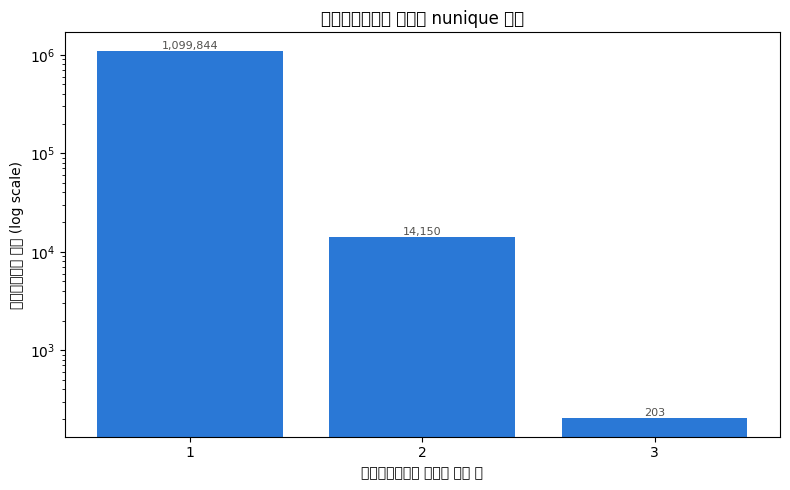

In [6]:
import matplotlib.pyplot as plt

name_nunique = df_all.groupby('상가업소번호')['상호명'].nunique()

dist = name_nunique.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(dist.index.astype(str), dist.values, color='#2a78d6')
ax.set_yscale('log')
ax.set_xlabel('상가업소번호당 상호명 종류 수')
ax.set_ylabel('상가업소번호 개수 (log scale)')
ax.set_title('상가업소번호별 상호명 nunique 분포')

for i, v in enumerate(dist.values):
    ax.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=8, color='#52514e')

plt.tight_layout()
plt.show()

##층수 현황 확인

C:\Users\seohg\AppData\Local\Temp\ipykernel_7132\638488623.py:17: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\seohg\AppData\Local\Temp\ipykernel_7132\638488623.py:17: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\seohg\AppData\Local\Temp\ipykernel_7132\638488623.py:17: UserWarning: Glyph 50629 (\N{HANGUL SYLLABLE EOB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\seohg\AppData\Local\Temp\ipykernel_7132\638488623.py:17: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\seohg\AppData\Local\Temp\ipykernel_7132\638488623.py:17: UserWarning: Glyph 48264 (\N{HANGUL SYLLABLE BEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\seohg\AppData\Local\Temp\ipykernel_7132\638488623.py:17: UserWarning: Glyph 54840 (\N{HANGUL SYLLABLE HO}) missing from font(s) Dej

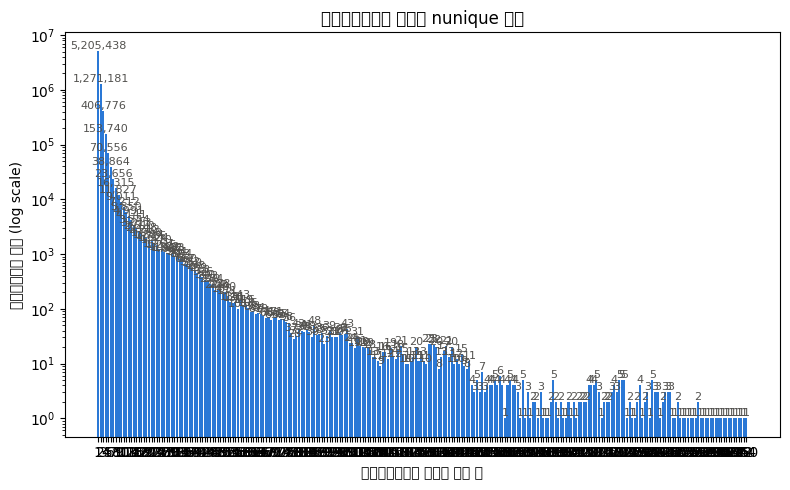

In [7]:
import matplotlib.pyplot as plt

floor_nunique = df_all.groupby(['건물관리번호', '층정보', 'period'])['상가업소번호'].nunique()

dist_2 = floor_nunique.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(dist_2.index.astype(str), dist_2.values, color='#2a78d6')
ax.set_yscale('log')
ax.set_xlabel('상가업소번호당 상호명 종류 수')
ax.set_ylabel('상가업소번호 개수 (log scale)')
ax.set_title('상가업소번호별 상호명 nunique 분포')

for i, v in enumerate(dist_2.values):
    ax.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=8, color='#52514e')

plt.tight_layout()
plt.show()

### 층수 입력 양식 및 이상치 확인

In [8]:
print(floor_nunique.sort_values(ascending=False).head(10))

건물관리번호                     층정보  period
1165010800113370006022600  1    202306    350
                                202303    344
                                202309    342
1156012100100550018000001  9    202503    338
1165010800113370006022600  1    202312    336
                                202403    327
                                202406    322
                                202409    314
                                202412    306
1165010800116250010023919  4    202506    302
Name: 상가업소번호, dtype: int64


In [9]:
print(dist_2.sort_values)

<bound method Series.sort_values of 상가업소번호
1      5205438
2      1271181
3       406776
4       153740
5        70556
        ...   
336          1
338          1
342          1
344          1
350          1
Name: count, Length: 256, dtype: int64>


In [10]:
dist_2_top = df_all[
    (df_all['건물관리번호'] == '1165010800113370006022600') & 
    (df_all['층정보'] == '1') & 
    (df_all['period'] == 202306)]
dist_2_top.drop(columns=[
    '상권업종대분류코드', '상권업종대분류명', '상권업종중분류코드',
       '상권업종중분류명', '상권업종소분류코드', '상권업종소분류명', '표준산업분류코드', '표준산업분류명', '시도코드',
       '시도명', '시군구코드', '시군구명', '행정동코드', '행정동명', '법정동코드', '법정동명', '지번코드',
       '대지구분코드', '대지구분명', '지번본번지', '지번부번지', '지번주소', '도로명코드'
       ], inplace=True)
dist_2_top

C:\Users\seohg\AppData\Local\Temp\ipykernel_7132\4129549545.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dist_2_top.drop(columns=[


,상가업소번호,상호명,지점명,도로명,건물본번지,건물부번지,건물관리번호,건물명,도로명주소,구우편번호,신우편번호,동정보,층정보,호정보,경도,위도,period
13488822,MA010120220805456801,해머헤드,NaN,서울특별시 서초구 강남대로51길,10.0,NaN,1165010800113370006022600,강남효성해링턴타워,서울특별시 서초구 강남대로51길 10,137860,6627,NaN,1,NaN,127.029261,37.491251,202306
13489089,MA010120220805464896,웰케어펫,NaN,서울특별시 서초구 강남대로51길,10.0,NaN,1165010800113370006022600,강남효성해링턴타워,서울특별시 서초구 강남대로51길 10,137860,6627,NaN,1,NaN,127.029261,37.491251,202306
13489479,MA010120220805474744,헤덴,NaN,서울특별시 서초구 강남대로51길,10.0,NaN,1165010800113370006022600,강남효성해링턴타워,서울특별시 서초구 강남대로51길 10,137860,6627,NaN,1,NaN,127.029261,37.491251,202306
13490203,MA010120220805496939,효령파트너스,NaN,서울특별시 서초구 강남대로51길,10.0,NaN,1165010800113370006022600,강남효성해링턴타워,서울특별시 서초구 강남대로51길 10,137860,6627,NaN,1,NaN,127.029261,37.491251,202306
13491124,MA010120220805526255,햄프트리,NaN,서울특별시 서초구 강남대로51길,10.0,NaN,1165010800113370006022600,강남효성해링턴타워,서울특별시 서초구 강남대로51길 10,137860,6627,NaN,1,NaN,127.029261,37.491251,202306
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13973441,MA0101202306A0004595,하나제이파트너스,NaN,서울특별시 서초구 강남대로51길,10.0,NaN,1165010800113370006022600,강남효성해링턴타워,서울특별시 서초구 강남대로51길 10,137860,6627,NaN,1,NaN,127.029260,37.491269,202306
13973895,MA0101202306A0019567,우주리얼티,NaN,서울특별시 서초구 강남대로51길,10.0,NaN,1165010800113370006022600,강남효성해링턴타워,서울특별시 서초구 강남대로51길 10,137860,6627,NaN,1,NaN,127.029260,37.491269,202306
13974408,MA0101202306A0034661,드레줄기획,NaN,서울특별시 서초구 강남대로51길,10.0,NaN,1165010800113370006022600,강남효성해링턴타워,서울특별시 서초구 강남대로51길 10,137860,6627,NaN,1,NaN,127.029260,37.491269,202306
13974415,MA0101202306A0075080,윤이엔엠,NaN,서울특별시 서초구 강남대로51길,10.0,NaN,1165010800113370006022600,강남효성해링턴타워,서울특별시 서초구 강남대로51길 10,137860,6627,NaN,1,NaN,127.029260,37.491269,202306


In [11]:
dist_2_top = df_all[
    (df_all['건물관리번호'] == '1165010800113370006022600') & 
    (df_all['층정보'] == '2') & 
    (df_all['period'] == 202306)]
dist_2_top.drop(columns=[
    '상권업종대분류코드', '상권업종대분류명', '상권업종중분류코드',
       '상권업종중분류명', '상권업종소분류코드', '상권업종소분류명', '표준산업분류코드', '표준산업분류명', '시도코드',
       '시도명', '시군구코드', '시군구명', '행정동코드', '행정동명', '법정동코드', '법정동명', '지번코드',
       '대지구분코드', '대지구분명', '지번본번지', '지번부번지', '지번주소', '도로명코드'
       ], inplace=True)
dist_2_top

C:\Users\seohg\AppData\Local\Temp\ipykernel_7132\2650034903.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dist_2_top.drop(columns=[


,상가업소번호,상호명,지점명,도로명,건물본번지,건물부번지,건물관리번호,건물명,도로명주소,구우편번호,신우편번호,동정보,층정보,호정보,경도,위도,period
13957693,MA0101202302A0106696,에끌로아트,NaN,서울특별시 서초구 강남대로51길,10.0,NaN,1165010800113370006022600,강남효성해링턴타워,서울특별시 서초구 강남대로51길 10,137860,6627,NaN,2,NaN,127.02926,37.491269,202306


In [12]:
raw = df_all[(df_all['건물관리번호'] == '1165010800113370006022600') & 
    (df_all['period'] == 202306)]
print(raw['층정보'].value_counts())   # 정규화 전 원본 값 그대로
print()
print(raw[['지번주소','도로명주소']].drop_duplicates().head(10))

층정보
1      350
B1      44
106      2
15       1
105      1
14       1
9        1
214      1
지        1
2        1
Name: count, dtype: int64

                          지번주소                 도로명주소
13488822  서울특별시 서초구 서초동 1337-6  서울특별시 서초구 강남대로51길 10


In [13]:
df_all['층정보'].value_counts()

층정보
1       6626573
2       2043589
3       1125841
4        689996
5        449769
         ...   
1301          1
1616          1
191           1
09            1
B8            1
Name: count, Length: 287, dtype: int64

# 건축물대장 결합 검증

1단계: 건축물대장 로드 → 2단계: 조인 키(PNU) 확인 → 3단계: 층 분할 로직 검증 → 4단계: 주용도별 층정보 신뢰도 확인

In [14]:
## 1단계: 건축물대장 로드 및 컬럼 확인
building_path = r"C:\Users\seohg\OneDrive\바탕 화면\2026\seoul datalob contest\서울시 건축물대장 표제부.csv"

try:
    df_building = pd.read_csv(building_path, encoding="cp949", low_memory=False)
except UnicodeDecodeError:
    # 파일 중간에 cp949로 디코딩 안 되는 바이트가 소수 존재 -> 깨진 문자만 대체하고 계속 진행
    df_building = pd.read_csv(building_path, encoding="cp949", encoding_errors="replace", low_memory=False)

print(df_building.shape)
print(df_building.columns.tolist())
df_building.head()

(593329, 62)
['대지위치', '시군구코드명', '법정동코드명', '대지구분코드명', '주지번', '부지번', '특수지명', '블록번호', '로트번호', '새주소도로코드명', '새주소법정동코드명', '새주소지상지하구분코드명', '새주소주지번', '새주소부지번', '건축물대장일련번호', '대장구분코드명', '대장종류코드명', '동명', '주부속구분코드명', '대지면적', '건축면적', '건폐율', '연면적', '용적률산정연면적', '용적률', '구조코드명', '기타구조정보', '주용도코드명', '기타용도내용', '지붕코드명', '기타지붕명', '세대수', '가구수', '호수', '지상층수', '지하층수', '높이', '승용승강기수', '비상용승강기수', '부속건축물수', '부속건축물면적', '총동연면적', '옥내기계식대수', '옥내기계식면적', '옥외기계식대수', '옥외기계식면적', '옥내자주식대수', '옥내자주식면적', '옥외자주식대수', '옥외자주식면적', '허가일자', '착공일자', '사용승인일자', '에너지효율등급값', '에너지절감률', 'EPI점수', '친환경건축물등급값', '친환경건축물인증점수', '지능형건축물등급값', '지능형건축물인증점수', '내진설계적용여부', '내진능력내용']


,대지위치,시군구코드명,법정동코드명,대지구분코드명,주지번,부지번,특수지명,블록번호,로트번호,새주소도로코드명,...,사용승인일자,에너지효율등급값,에너지절감률,EPI점수,친환경건축물등급값,친환경건축물인증점수,지능형건축물등급값,지능형건축물인증점수,내진설계적용여부,내진능력내용
0,서울특별시 강서구 방화동 246-66,서울특별시 강서구,방화동,대지,246,66,NaN,NaN,NaN,방화대로,...,1989-06-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
1,서울특별시 마포구 아현동 751-11,서울특별시 마포구,아현동,대지,751,11,NaN,NaN,NaN,환일길,...,1984-08-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
2,서울특별시 양천구 신월동 987-1,서울특별시 양천구,신월동,대지,987,1,NaN,NaN,NaN,신월로,...,1988-04-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
3,서울특별시 양천구 신정동 87-39,서울특별시 양천구,신정동,대지,87,39,NaN,NaN,NaN,신목로,...,1990-12-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
4,서울특별시 강서구 화곡동 102-29,서울특별시 강서구,화곡동,대지,102,29,NaN,NaN,NaN,까치산로4길,...,1990-08-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN


In [ ]:
## 2단계: 조인 키 존재 여부 확인

#PNU19 = 건물관리번호 앞 19자리(법정동코드 10 + 대지구분 1 + 본번 4 + 부번 4)를 직접 슬라이싱해서 만든 값
# 건물관리번호 샘플 (25자리 = 법정동코드10 + 대지구분1 + 지번본번4 + 지번부번4 + 건물일련번호6)
print(df_all['건물관리번호'].dropna().head(5).tolist())

# 건축물대장에 숫자형 법정동코드가 있는지 확인 -> 없고 법정동코드명(텍스트)만 존재
print([c for c in df_building.columns if '법정동' in c or '시군구' in c])

# df_all 자체의 (시군구명, 법정동명) -> 법정동코드 매핑표를 만들어 건축물대장에 역매핑
code_map = (
    df_all[['시군구명', '법정동명', '법정동코드']]
    .dropna()
    .drop_duplicates()
    .set_index(['시군구명', '법정동명'])['법정동코드']
    .to_dict()
)

df_building['시군구명_정리'] = df_building['시군구코드명'].str.replace('서울특별시 ', '', regex=False)
df_building['법정동코드_추정'] = df_building.apply(
    lambda r: code_map.get((r['시군구명_정리'], r['법정동코드명'])), axis=1
)
# apply 결과가 정수/None 혼합이라 float64로 승격되면서 astype(str) 시 "1165010800.0"처럼
# 소수점이 끼어드는 문제가 있었음 -> nullable 정수형(Int64)으로 고정해서 방지
df_building['법정동코드_추정'] = df_building['법정동코드_추정'].astype('Int64')
print(f"건축물대장 -> 법정동코드 역매핑 성공률: {df_building['법정동코드_추정'].notna().mean() * 100:.2f}%")

# 도로명주소 vs 대지위치 매칭률 (요청하신 방식) - 대지위치는 지번주소 형식이라 도로명주소와는 형식이 달라 낮게 나올 수 있음
df_all['도로명주소_정규화'] = df_all['도로명주소'].str.replace(r'\s+', '', regex=True)
df_building['대지위치_정규화'] = df_building['대지위치'].astype(str).str.replace(r'\s+', '', regex=True)

road_set = set(df_all['도로명주소_정규화'].dropna())
build_addr_set = set(df_building['대지위치_정규화'].dropna())
overlap = road_set & build_addr_set
print(f"도로명주소 vs 대지위치 매칭률: {len(overlap) / len(road_set) * 100:.2f}% "
      f"({len(overlap)} / {len(road_set)})")

# 참고: 형식이 같은 지번주소로 비교하면 매칭률이 훨씬 높음
df_all['지번주소_정규화'] = df_all['지번주소'].str.replace(r'\s+', '', regex=True)
jibun_set = set(df_all['지번주소_정규화'].dropna())
overlap_jibun = jibun_set & build_addr_set
print(f"[참고] 지번주소 vs 대지위치 매칭률: {len(overlap_jibun) / len(jibun_set) * 100:.2f}% "
      f"({len(overlap_jibun)} / {len(jibun_set)})")

In [16]:
## 2단계 (계속): PNU(법정동코드+대지구분+본번+부번) 조인 키 생성

# 건축물대장 쪽 PNU19
jibun_map = {'대지': '1', '산': '2'}  # '블록' 등 새주소 전용 필지는 매칭 대상에서 제외
df_building['대지구분코드_추정'] = df_building['대지구분코드명'].map(jibun_map)

mask = df_building['법정동코드_추정'].notna() & df_building['대지구분코드_추정'].notna()
df_building.loc[mask, 'PNU19'] = (
    df_building.loc[mask, '법정동코드_추정'].astype(str)
    + df_building.loc[mask, '대지구분코드_추정'].astype(str)
    + df_building.loc[mask, '주지번'].astype(int).astype(str).str.zfill(4)
    + df_building.loc[mask, '부지번'].astype(int).astype(str).str.zfill(4)
)
print(f"건축물대장 PNU19 생성 성공: {df_building['PNU19'].notna().mean() * 100:.2f}%")

# df_all 쪽 PNU19 (이미 갖고 있는 지번 관련 컬럼으로 직접 조립)
df_all['PNU19'] = (
    df_all['법정동코드'].astype(str)
    + df_all['대지구분코드'].fillna(1).astype(int).astype(str)
    + df_all['지번본번지'].fillna(0).astype(int).astype(str).str.zfill(4)
    + df_all['지번부번지'].fillna(0).astype(int).astype(str).str.zfill(4)
)

# fan-out 점검: 같은 PNU19(필지)에 건물(동)이 여러 개 딸려 있는 경우
grp = df_building.dropna(subset=['PNU19']).groupby('PNU19')
dup_pnu = grp.size()
print(f"고유 PNU19: {len(dup_pnu)}개, 동이 2개 이상인 PNU19: {(dup_pnu > 1).sum()}개 "
      f"({(dup_pnu > 1).mean() * 100:.2f}%)")

floor_nunique_by_pnu = grp['지상층수'].nunique()
print(f"그 중 지상층수 값이 서로 다른 PNU19: {(floor_nunique_by_pnu > 1).sum()}개 "
      f"({(floor_nunique_by_pnu > 1).mean() * 100:.2f}% of all PNU19)")

# 필지 단위로 집계 (동이 여럿이면 최댓값을 총층수로 사용)
building_agg = grp.agg(총층수=('지상층수', 'max'), 동개수=('지상층수', 'size'))

# df_all -> 건축물대장 매칭 성공률
pnu_match_rate = df_all['PNU19'].isin(building_agg.index).mean()
print(f"df_all PNU19가 건축물대장에 매칭되는 비율: {pnu_match_rate * 100:.2f}%")

건축물대장 PNU19 생성 성공: 99.88%
고유 PNU19: 518853개, 동이 2개 이상인 PNU19: 24495개 (4.72%)
그 중 지상층수 값이 서로 다른 PNU19: 12581개 (2.42% of all PNU19)
df_all PNU19가 건축물대장에 매칭되는 비율: 0.00%


In [17]:
## 3단계: 층 분할 로직 검증

def split_floor_unit(code, total_floors):
    code = str(code)
    if not code.isdigit():
        return code, None
    if total_floors is None or total_floors <= 0:
        return code, None
    for floor_digits in range(len(code) - 1, 0, -1):
        floor_part = int(code[:floor_digits])
        if 1 <= floor_part <= total_floors:
            return str(floor_part), code[floor_digits:]
    return code[0], code[1:]


# 층정보가 3자리 이상 숫자인 행만 대상으로, PNU19로 총층수를 붙인다
target = df_all[df_all['층정보'].fillna('').str.fullmatch(r'\d{3,}')].merge(
    building_agg, left_on='PNU19', right_index=True, how='left'
)
print(f"층정보 3자리 이상 숫자인 행: {len(target)}개, 총층수 매칭 성공: {target['총층수'].notna().sum()}개 "
      f"({target['총층수'].notna().mean() * 100:.2f}%)")

split_result = target.apply(lambda r: split_floor_unit(r['층정보'], r['총층수']), axis=1)
target['층_분할'] = split_result.apply(lambda t: t[0])
target['호_분할'] = split_result.apply(lambda t: t[1])

target.sample(min(30, len(target)), random_state=42)[
    ['건물관리번호', '층정보', '총층수', '동개수', '층_분할', '호_분할', 'period']
]

층정보 3자리 이상 숫자인 행: 9104개, 총층수 매칭 성공: 0개 (0.00%)


,건물관리번호,층정보,총층수,동개수,층_분할,호_분할,period
18540593,1111012200100240000032840,701,NaN,NaN,7,01,202510
8729501,1150010400114790004009672,112,NaN,NaN,1,12,202012
8877989,1150010900108140000000199,505,NaN,NaN,5,05,202103
6369804,1153010200108110000026784,101,NaN,NaN,1,01,201909
7397575,1144010500104940041004081,601,NaN,NaN,6,01,202006
8928274,1171010800103250003000001,135,NaN,NaN,1,35,202103
7974716,NaN,201,NaN,NaN,2,01,202009
3632602,1174010500104540001003206,1502,NaN,NaN,1,502,201803
14259131,1165010600100350008019673,401,NaN,NaN,4,01,202309
6409454,1165010700100300002018419,220,NaN,NaN,2,20,201909


In [18]:
## 3단계 (계속): 이상치(분할된 층 > 총층수) 개수/비율

def is_outlier(row):
    if pd.isna(row['총층수']):
        return None
    try:
        return int(row['층_분할']) > row['총층수']
    except ValueError:
        return None

target['이상치여부'] = target.apply(is_outlier, axis=1)
valid = target['이상치여부'].notna()
n_outlier = target.loc[valid, '이상치여부'].sum()
n_valid = valid.sum()
print(f"총층수가 매칭된 행 중 분할된 층이 총층수를 초과하는 경우: {int(n_outlier)} / {n_valid} "
      f"({n_outlier / n_valid * 100:.2f}%)")

target.loc[valid & target['이상치여부']].head(15)[
    ['건물관리번호', '층정보', '총층수', '동개수', '층_분할', '호_분할', 'period']
]

총층수가 매칭된 행 중 분할된 층이 총층수를 초과하는 경우: 0 / 0 (nan%)


C:\Users\seohg\AppData\Local\Temp\ipykernel_7132\4270418385.py:16: RuntimeWarning: invalid value encountered in scalar divide
  f"({n_outlier / n_valid * 100:.2f}%)")


,건물관리번호,층정보,총층수,동개수,층_분할,호_분할,period


In [19]:
## 4단계: 오피스텔/아파트 등 주거계열 건물의 층정보 신뢰도 확인

# 참고: 아파트/연립주택/다세대주택/오피스텔은 주용도코드명 값 자체로는 존재하지 않고
# '공동주택'(아파트/연립/다세대 포함) 또는 '업무시설'(오피스텔 포함 가능) 등으로 묶여 있을 수 있음 -> 먼저 확인
print(df_building['주용도코드명'].value_counts().head(20))

# 한 PNU19(필지)에 동이 여럿이면 가장 흔한 주용도를 대표값으로 사용
def _mode_or_none(s):
    s = s.dropna()
    if len(s) == 0:
        return None
    return s.value_counts().idxmax()

pnu_to_use = grp['주용도코드명'].agg(_mode_or_none)

df_all['주용도코드명'] = df_all['PNU19'].map(pnu_to_use)

ratio = (
    df_all.dropna(subset=['주용도코드명'])
    .assign(is_1f=lambda d: d['층정보'] == '1')
    .groupby('주용도코드명')['is_1f']
    .agg(층1_비율='mean', 표본수='size')
)
ratio['층1_비율'] = ratio['층1_비율'] * 100
ratio = ratio.sort_values('표본수', ascending=False)

ratio.head(25)

주용도코드명
단독주택          290108
공동주택          142010
제2종근린생활시설      63406
제1종근린생활시설      57890
업무시설           10290
교육연구시설          8262
노유자시설           3252
종교시설            2954
공장              2354
숙박시설            1992
자동차관련시설         1889
창고시설            1583
문화및집회시설         1422
판매시설            1228
근린생활시설           959
의료시설             799
위험물저장및처리시설       669
운동시설             356
교정및군사시설          290
운수시설             268
Name: count, dtype: int64


,층1_비율,표본수
주용도코드명,,


In [20]:
## 4단계 (계속): 주거계열 vs 근린생활시설 비교

residential = ['단독주택', '공동주택']
commercial = ['제1종근린생활시설', '제2종근린생활시설', '업무시설']

print(ratio.loc[ratio.index.isin(residential + commercial)])

print(f"\n주거계열(단독+공동주택) 평균 층1 비율: {ratio.loc[ratio.index.isin(residential), '층1_비율'].mean():.2f}%")
print(f"근린생활+업무시설 평균 층1 비율: {ratio.loc[ratio.index.isin(commercial), '층1_비율'].mean():.2f}%")

Empty DataFrame
Columns: [층1_비율, 표본수]
Index: []

주거계열(단독+공동주택) 평균 층1 비율: nan%
근린생활+업무시설 평균 층1 비율: nan%
